# Figure4

In [1]:
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import pandas as pd 
import matplotlib.colors as mcolors
from matplotlib import rcParams, rcParamsDefault
from matplotlib.lines import Line2D
from src.utils.tools import seed_everything
import matplotlib.patches as mpatches

EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}


/Users/wanghan/miniconda3/envs/deepburst/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 6 ,
        'axes.titleweight' :'regular',
        
        'figure.titleweight' : 'regular' ,
        'figure.titlesize' : 6 ,
        'figure.labelsize' : 6 ,
        'figure.labelweight' : 'regular' , 
        
        'axes.labelsize' : 6 ,
        'axes.labelpad' : 2 ,
        'axes.labelweight' : 'regular' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'legend.fontsize' : 6 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'black',   
        'legend.edgecolor': 'black',
        'legend.labelcolor': 'black',  # 设置图例标签字体颜色（在新版matplotlib中支持）
        'axes.edgecolor': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'axes.titlecolor': 'black',
        'axes.labelcolor': 'black',

        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        'xtick.major.width': 0.5,  # X轴刻度主刻度线宽度
        'ytick.major.width': 0.5, 
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        'text.color': 'black',  # 全局文字颜色

        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )

COLOR_MAP = {'H3K4me1':'#A28F19','H3K4me3':'#7FA5D0','H3K9me3':'#FDE4A4','H3K27ac':'#F5B6AC','H3K27me3':'#7CA68B','H3K36me3':'#80448A','H3K9ac':'#C7886D'}


# Figure 4A

Source data saved to scripts/figures/v8/source_data/fig4a.csv


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_10306/3653508840.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


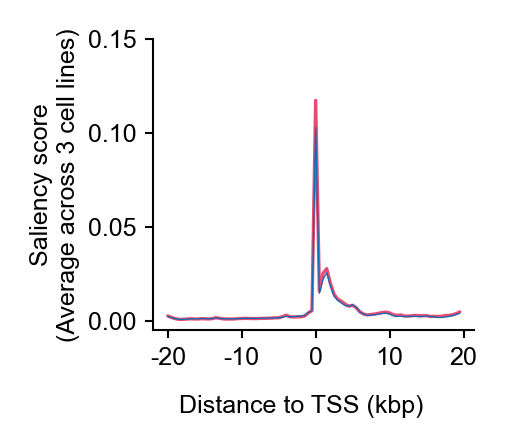

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines

fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(4/2.54, 3.5/2.54))
palette = ['#E94C72', '#036EB8']

# =========================================================
# LOAD DATA
# =========================================================
eid = 'E003'

with open(f'extra/results/{eid}_bf_deeplift_distribution.npy', 'rb') as f:
    distribution1_E003 = np.load(f)

with open(f'extra/results/{eid}_bs_deeplift_distribution.npy', 'rb') as f:
    distribution2_E003 = np.load(f)


eid = 'E116'

with open(f'extra/results/{eid}_bf_deeplift_distribution.npy', 'rb') as f:
    distribution1_E116 = np.load(f)

with open(f'extra/results/{eid}_bs_deeplift_distribution.npy', 'rb') as f:
    distribution2_E116 = np.load(f)


eid = 'E118'

with open(f'extra/results/{eid}_bf_deeplift_distribution.npy', 'rb') as f:
    distribution1_E118 = np.load(f)

with open(f'extra/results/{eid}_bs_deeplift_distribution.npy', 'rb') as f:
    distribution2_E118 = np.load(f)


# =========================================================
# AVERAGE ACROSS THREE CELL LINES
# =========================================================
distribution1 = (distribution1_E003 + distribution1_E116 + distribution1_E118) / 3
distribution2 = (distribution2_E003 + distribution2_E116 + distribution2_E118) / 3


# =========================================================
# SOURCE DATA
# =========================================================
position_index = np.arange(len(distribution1))
distance_to_tss_kbp = (position_index - 40) / 2

source_data_list = []

profiles = [
    ('E003', 'H1', 'BF', distribution1_E003),
    ('E003', 'H1', 'BS', distribution2_E003),
    ('E116', 'GM12878', 'BF', distribution1_E116),
    ('E116', 'GM12878', 'BS', distribution2_E116),
    ('E118', 'HepG2', 'BF', distribution1_E118),
    ('E118', 'HepG2', 'BS', distribution2_E118),
    ('Average', 'Average across 3 cell lines', 'BF', distribution1),
    ('Average', 'Average across 3 cell lines', 'BS', distribution2),
]

for source_eid, cell_type, target, values in profiles:
    source_panel = pd.DataFrame({'eid': source_eid, 'cell_type': cell_type, 'target': target, 'position_index': position_index, 'distance_to_TSS_kbp': distance_to_tss_kbp, 'saliency_score': values})
    source_data_list.append(source_panel)

source_data = pd.concat(source_data_list, ignore_index=True)

source_dir = 'scripts/figures/v8/source_data'
os.makedirs(source_dir, exist_ok=True)
source_data.to_csv(f'{source_dir}/fig4a.csv', index=False)

print(f'Source data saved to {source_dir}/fig4a.csv')


# =========================================================
# PLOT
# =========================================================
sns.lineplot(distribution1, color=palette[0], linewidth=0.8, ax=ax)
sns.lineplot(distribution2, color=palette[1], linewidth=0.3, ax=ax)

ax.legend().remove()
ax.set_xticks([i for i in range(0, 81, 20)])
ax.set_yticks([i/100 for i in range(0, 16, 5)])

xticklabels = [int((i - 40) / 2) for i in range(0, 81, 20)]
ax.set_xticklabels(xticklabels)

ax.set_ylabel('Saliency score\n(Average across 3 cell lines)', ha='center')
fig.supxlabel('Distance to TSS (kbp)', x=0.6, fontsize=6)


# =========================================================
# LEGEND
# =========================================================
legend_lines = [
    mlines.Line2D([], [], color=palette[0], linestyle='-', label='BF'),
    mlines.Line2D([], [], color=palette[1], linestyle='-', label='BS'),
]

# legend = fig.legend(handles=legend_lines, title='', loc='upper left', bbox_to_anchor=(0.98, 1.02), title_fontsize=6, fontsize=5, ncol=1, edgecolor='none', handlelength=2/2.54, columnspacing=1.5)


# =========================================================
# SAVE FIGURE
# =========================================================
plt.savefig('extra/figures/v8/Figure4A.eps', format='eps', bbox_inches='tight')
plt.show()

# Figure 4B

Source data saved to scripts/figures/v8/source_data/fig4b.csv


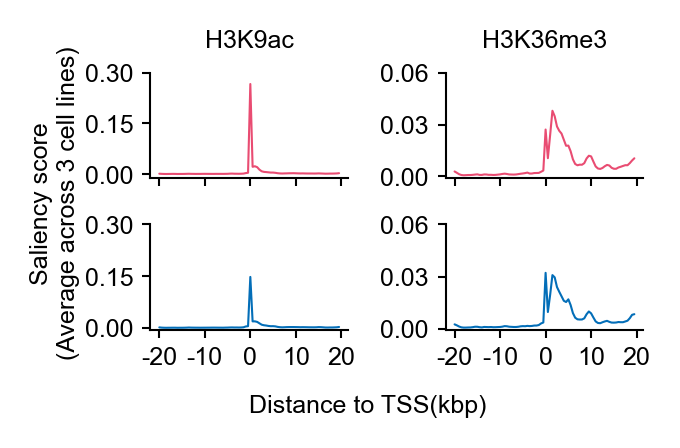

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines

MARKS = ["H3K4me1", "H3K4me3", "H3K9me3", "H3K27me3", "H3K36me3", "H3K27ac", "H3K9ac"]
yticks = ['H3K9ac', 'H3K36me3']
idxes = [MARKS.index(mark) for mark in yticks]
palette = ['#E94C72', '#036EB8']

# =========================================================
# LOAD DATA
# =========================================================
eid = 'E003'

with open(f'extra/results/{eid}_bf_deeplift_attributions.npy', 'rb') as f:
    attributions1_E003 = np.load(f)

with open(f'extra/results/{eid}_bs_deeplift_attributions.npy', 'rb') as f:
    attributions2_E003 = np.load(f)


eid = 'E116'

with open(f'extra/results/{eid}_bf_deeplift_attributions.npy', 'rb') as f:
    attributions1_E116 = np.load(f)

with open(f'extra/results/{eid}_bs_deeplift_attributions.npy', 'rb') as f:
    attributions2_E116 = np.load(f)


eid = 'E118'

with open(f'extra/results/{eid}_bf_deeplift_attributions.npy', 'rb') as f:
    attributions1_E118 = np.load(f)

with open(f'extra/results/{eid}_bs_deeplift_attributions.npy', 'rb') as f:
    attributions2_E118 = np.load(f)


# =========================================================
# AVERAGE ACROSS THREE CELL LINES
# =========================================================
attributions1 = (attributions1_E003 + attributions1_E116 + attributions1_E118) / 3
attributions2 = (attributions2_E003 + attributions2_E116 + attributions2_E118) / 3

attributions1_plot = attributions1[idxes]
attributions2_plot = attributions2[idxes]


# =========================================================
# SOURCE DATA
# =========================================================
position_index = np.arange(attributions1.shape[1])
distance_to_tss_kbp = (position_index - 40) / 2

source_data_list = []

profiles = [
    ('E003', 'H1', 'BF', attributions1_E003),
    ('E003', 'H1', 'BS', attributions2_E003),
    ('E116', 'GM12878', 'BF', attributions1_E116),
    ('E116', 'GM12878', 'BS', attributions2_E116),
    ('E118', 'HepG2', 'BF', attributions1_E118),
    ('E118', 'HepG2', 'BS', attributions2_E118),
    ('Average', 'Average across 3 cell lines', 'BF', attributions1),
    ('Average', 'Average across 3 cell lines', 'BS', attributions2),
]

for source_eid, cell_type, target, matrix in profiles:
    for mark in yticks:
        mark_idx = MARKS.index(mark)
        source_panel = pd.DataFrame({'eid': source_eid, 'cell_type': cell_type, 'target': target, 'histone_mark': mark, 'position_index': position_index, 'distance_to_TSS_kbp': distance_to_tss_kbp, 'saliency_score': matrix[mark_idx]})
        source_data_list.append(source_panel)

source_data = pd.concat(source_data_list, ignore_index=True)

source_columns = ['eid', 'cell_type', 'target', 'histone_mark', 'position_index', 'distance_to_TSS_kbp', 'saliency_score']
source_data = source_data[source_columns]

source_dir = 'scripts/figures/v8/source_data'
os.makedirs(source_dir, exist_ok=True)
source_data.to_csv(f'{source_dir}/fig4b.csv', index=False)

print(f'Source data saved to {source_dir}/fig4b.csv')


# =========================================================
# FIGURE
# =========================================================
fig, ax = plt.subplots(2, 2, constrained_layout=True, figsize=(5/2.54, 3.5/2.54))

xticks = [i for i in range(0, 81, 10)]


# =========================================================
# BF
# =========================================================
for _idx, mark in enumerate(yticks):
    sns.lineplot(attributions1_plot[_idx], label=mark, ax=ax[0, _idx], color=palette[0], linewidth=0.5)

    ax[0, _idx].legend().remove()

    xticklabels = [int((i - 40) / 2) for i in range(0, 81, 20)]

    ax[0, _idx].set_xticks(np.arange(0, 81, 20), labels='')
    ax[0, _idx].set_xlabel('', fontsize=6, ha='center')
    ax[0, _idx].set_title(mark)


# =========================================================
# BS
# =========================================================
for _idx, mark in enumerate(yticks):
    sns.lineplot(attributions2_plot[_idx], label=mark, ax=ax[1, _idx], color=palette[1], linewidth=0.5)

    ax[1, _idx].legend().remove()

    xticklabels = [int((i - 40) / 2) for i in range(0, 81, 20)]

    ax[1, _idx].set_xticks(np.arange(0, 81, 20), labels=xticklabels)
    ax[1, _idx].set_xlabel('', fontsize=6, ha='center')


# =========================================================
# AXIS LABELS
# =========================================================
fig.supxlabel('Distance to TSS(kbp)', fontsize=6, x=0.5)
fig.supylabel('Saliency score\n(Average across 3 cell lines)', fontsize=6, x=-0.03, y=0.55, ha='center')

ax[0, 0].set_yticks([i/100 for i in range(0, 40, 15)])
ax[0, 1].set_yticks([i/100 for i in range(0, 7, 3)])
ax[1, 0].set_yticks([i/100 for i in range(0, 40, 15)])
ax[1, 1].set_yticks([i/100 for i in range(0, 7, 3)])


# =========================================================
# LEGEND
# =========================================================
legend_lines = [
    mlines.Line2D([], [], color=palette[0], linestyle='-', label='BF'),
    mlines.Line2D([], [], color=palette[1], linestyle='-', label='BS'),
]


# =========================================================
# SAVE FIGURE
# =========================================================
plt.savefig('extra/figures/v8/Figure4B.eps', format='eps', bbox_inches='tight')
plt.show()

# Figure 4C

Source data saved to scripts/figures/v8/source_data/fig4c.csv
target  keep_mark
BF      H3K27ac      4
        H3K27me3     4
        H3K36me3     4
        H3K4me1      4
        H3K4me3      4
        H3K9ac       4
        H3K9me3      4
BS      H3K27ac      4
        H3K27me3     4
        H3K36me3     4
        H3K4me1      4
        H3K4me3      4
        H3K9ac       4
        H3K9me3      4
dtype: int64


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_10306/719799468.py:114: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=1)


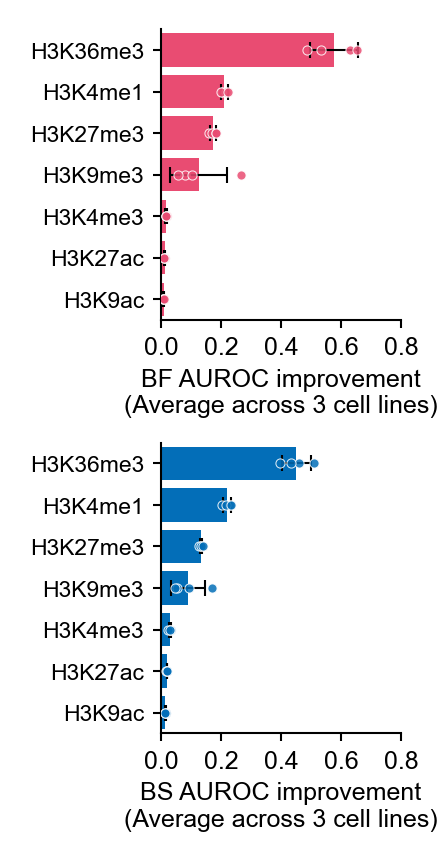

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(2, 1, constrained_layout=True, figsize=(3.5/2.54, 7/2.54))

palette = ['#E94C72', '#036EB8']
source_data_list = []

order = pd.Index(["H3K36me3", "H3K4me1", "H3K27me3", "H3K9me3", "H3K4me3", "H3K27ac", "H3K9ac"], name='marks')


# =========================================================
# PANEL 1: BF
# =========================================================
target = 'bf'

data_1 = pd.read_csv(f'extra/results/one_feature_indicators_{target}_para.csv')
data_2 = pd.read_csv(f'extra/results/one_feature_indicators_distance_1000_{target}_para.csv')

data = pd.merge(data_1, data_2, on=['eid', 'keep_mark', 'fold'])
data['increase'] = data['auc_x'] / data['auc_y'] - 1

# Average across 3 cell lines within each fold
data = data[['keep_mark', 'fold', 'increase']].groupby(['keep_mark', 'fold'], as_index=False).agg('mean')

# =========================================================
# SOURCE DATA: BF
# =========================================================
source_panel = data.copy()
source_panel['target'] = 'BF'
source_panel['aggregation'] = 'Mean across H1, HepG2, and GM12878 within each fold'
source_data_list.append(source_panel)

summary = data.groupby('keep_mark')['increase'].agg(['mean', 'std']).reindex(order)

y_pos = np.arange(len(order))

ax[0].barh(y_pos, summary['mean'].values, color=palette[0], linewidth=0, height=0.8)

ax[0].errorbar(summary['mean'].values, y_pos, xerr=summary['std'].values, fmt='none', ecolor='black', elinewidth=0.5, capsize=2, capthick=0.5)

sns.stripplot(data=data, x='increase', y='keep_mark', order=order, color=palette[0], jitter=0, size=2.2, alpha=0.85, linewidth=0.25, edgecolor='white', ax=ax[0], legend=False)

ax[0].set_yticks(y_pos)
ax[0].set_yticklabels(order, fontsize=5.5)
ax[0].set_xticks([i/10 for i in range(0, 9, 2)])
ax[0].set_yticks([mark for mark in order], labels=[mark for mark in order], fontsize=5.5)
ax[0].set_ylabel('')
ax[0].set_xlabel('BF AUROC improvement\n(Average across 3 cell lines)')


# =========================================================
# PANEL 2: BS
# =========================================================
target = 'bs'

data_1 = pd.read_csv(f'extra/results/one_feature_indicators_{target}_para.csv')
data_2 = pd.read_csv(f'extra/results/one_feature_indicators_distance_1000_{target}_para.csv')

data = pd.merge(data_1, data_2, on=['eid', 'keep_mark', 'fold'])
data['increase'] = data['auc_x'] / data['auc_y'] - 1

# Average across 3 cell lines within each fold
data = data[['keep_mark', 'fold', 'increase']].groupby(['keep_mark', 'fold'], as_index=False).agg('mean')

# =========================================================
# SOURCE DATA: BS
# =========================================================
source_panel = data.copy()
source_panel['target'] = 'BS'
source_panel['aggregation'] = 'Mean across H1, HepG2, and GM12878 within each fold'
source_data_list.append(source_panel)

summary = data.groupby('keep_mark')['increase'].agg(['mean', 'std']).reindex(order)

y_pos = np.arange(len(order))

ax[1].barh(y_pos, summary['mean'].values, color=palette[1], linewidth=0, height=0.8)

ax[1].errorbar(summary['mean'].values, y_pos, xerr=summary['std'].values, fmt='none', ecolor='black', elinewidth=0.5, capsize=2, capthick=0.5)

sns.stripplot(data=data, x='increase', y='keep_mark', order=order, color=palette[1], jitter=0, size=2.2, alpha=0.85, linewidth=0.25, edgecolor='white', ax=ax[1], legend=False)

ax[1].set_yticks(y_pos)
ax[1].set_yticklabels(order, fontsize=5.5)
ax[1].set_xticks([i/10 for i in range(0, 9, 2)])
ax[1].set_yticks([mark for mark in order], labels=[mark for mark in order], fontsize=5.5)
ax[1].set_ylabel('')
ax[1].set_xlabel('BS AUROC improvement\n(Average across 3 cell lines)')


# =========================================================
# SOURCE DATA
# =========================================================
source_data = pd.concat(source_data_list, ignore_index=True)

source_columns = ['target', 'keep_mark', 'fold', 'increase', 'aggregation']
source_data = source_data[source_columns]

source_dir = 'scripts/figures/v8/source_data'
os.makedirs(source_dir, exist_ok=True)
source_data.to_csv(f'{source_dir}/fig4c.csv', index=False)

print(f'Source data saved to {source_dir}/fig4c.csv')
print(source_data.groupby(['target', 'keep_mark']).size())


# =========================================================
# LAYOUT
# =========================================================
fig.subplots_adjust(hspace=1)

plt.savefig('extra/figures/v8/Figure4C.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Figure 4D

Source data saved to scripts/figures/v8/source_data/fig4d.csv
target  cell_type  distance
BF      GM12878    1000        4
                   2000        4
                   5000        4
                   10000       4
                   20000       4
                   40000       4
        H1         1000        4
                   2000        4
                   5000        4
                   10000       4
                   20000       4
                   40000       4
        HepG2      1000        4
                   2000        4
                   5000        4
                   10000       4
                   20000       4
                   40000       4
BS      GM12878    1000        4
                   2000        4
                   5000        4
                   10000       4
                   20000       4
                   40000       4
        H1         1000        4
                   2000        4
                   5000        4
                   

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_10306/1422026725.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_10306/1422026725.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])


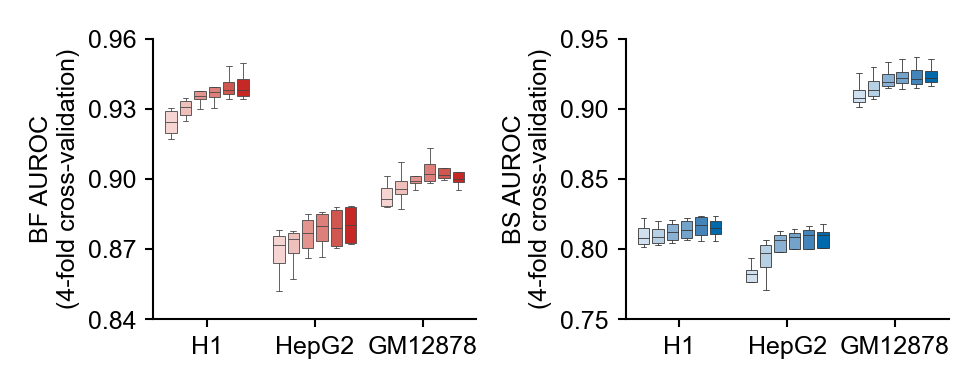

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

# =========================================================
# LOAD DATA
# =========================================================
target = 'bs'
data_bs = pd.read_csv(f'extra/results/distance_{target}_para.csv', sep='\t')
data_bs['auc'] = data_bs['auc'] / 100
data_bs['target'] = 'BS'

target = 'bf'
data_bf = pd.read_csv(f'extra/results/distance_{target}_para.csv', sep='\t')
data_bf['auc'] = data_bf['auc'] / 100
data_bf['target'] = 'BF'

# =========================================================
# SOURCE DATA
# =========================================================
source_data = pd.concat([data_bf, data_bs], ignore_index=True)
source_data['cell_type'] = source_data['eid'].map(EIDS_TO_CELLTYPES)

source_columns = ['eid', 'cell_type', 'target', 'distance', 'fold', 'auc']
source_data = source_data[[col for col in source_columns if col in source_data.columns]]

source_dir = 'scripts/figures/v8/source_data'
os.makedirs(source_dir, exist_ok=True)
source_data.to_csv(f'{source_dir}/fig4d.csv', index=False)

print(f'Source data saved to {source_dir}/fig4d.csv')
print(source_data.groupby(['target', 'cell_type', 'distance']).size())

# =========================================================
# FIGURE
# =========================================================
fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(8/2.54, 3/2.54))

order = pd.Index(["E003", "E118", "E116"], name='marks')

# =========================================================
# BF
# =========================================================
palette = ['#F5D4D2', '#EFBFBB', '#E3948F', '#DD7F7B', '#D05750', '#C52825']

sns.boxplot(data=data_bf, x='eid', y='auc', hue='distance', ax=ax[0], order=order, linewidth=0.2, fliersize=0, gap=0.2, width=0.8, palette=palette, saturation=1)

ax[0].set_xlabel('')
ax[0].set_ylabel('BF AUROC\n(4-fold cross-validation)', fontsize=6)
ax[0].legend().remove()
ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[0].set_ylim(0.84)

yticks = [i/100 for i in range(84, 97, 3)]
yticklabels = [f"{i:.2f}" for i in yticks]
ax[0].set_yticks(yticks, labels=yticklabels)

# =========================================================
# BS
# =========================================================
palette = ['#D0E0EE', '#B7D0E4', '#8AB1D4', '#73A3CB', '#4384BA', '#006AAC']

sns.boxplot(data=data_bs, x='eid', y='auc', hue='distance', ax=ax[1], order=order, linewidth=0.2, fliersize=0, gap=0.2, width=0.8, palette=palette, saturation=1)

ax[1].set_ylabel('BS AUROC\n(4-fold cross-validation)', fontsize=6)
ax[1].set_xlabel('')
ax[1].legend().remove()
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[1].set_ylim(0.75)

yticks = [i/100 for i in range(75, 96, 5)]
yticklabels = [f"{i:.2f}" for i in yticks]
ax[1].set_yticks(yticks, labels=yticklabels)

# =========================================================
# LEGEND
# =========================================================
handles, labels = ax[0].get_legend_handles_labels()
labels = ["1", "2", "5", "10", "20", "40"]

# fig.legend(handles, labels, title='Receptive field(kbp)', loc='upper left', bbox_to_anchor=(0.98, 1.02), title_fontsize=6, fontsize=5, ncol=1, edgecolor='none', handlelength=1.3, columnspacing=1.5)

# =========================================================
# SAVE FIGURE
# =========================================================
plt.savefig('extra/figures/v7/Figure4D.eps', format='eps', bbox_inches='tight')
plt.show()

# Figure 4F

Source data saved to scripts/figures/v8/source_data/fig4f.csv
region_group
High-attention region    18749
Low-attention region     59028
dtype: int64
U = 908592456.5
pval = 0.0000000000e+00
n_high = 18749
n_low = 59028
     region_type      mean       std  count       sem
0      attention  0.485309  0.252600  18749  0.001845
1  non_attention  0.203861  0.150443  59028  0.000619


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_18022/2855072459.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=agg_overlap, x='cres_density', y='region_type', palette=['#E64B35', '#4DBBD5'], order=order, linewidth=0.5, cut=0, scale='width')
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_18022/2855072459.py:70: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(data=agg_overlap, x='cres_density', y='region_type', palette=['#E64B35', '#4DBBD5'], order=order, linewidth=0.5, cut=0, scale='width')
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_18022/2855072459.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fix

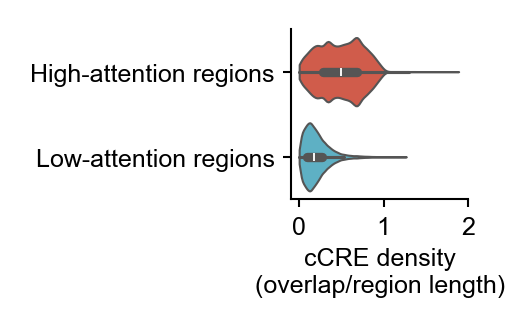

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

_eid = 'E116'

# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv(f'extra/results/attention_overlap_{_eid}.csv')

# ---- 计算每个区域的长度 ----
df['region_length'] = df['region_end'] - df['region_start']

# ---- 对每个 region 汇总 overlap 长度 ----
agg_overlap = df.groupby(['gene_id', 'region_type', 'region_start', 'region_end'], as_index=False).agg(overlap_length=('overlap_length', 'sum'), region_length=('region_end', lambda x: x.iloc[0] - df.loc[x.index[0], 'region_start']))

agg_overlap['cres_density'] = agg_overlap['overlap_length'] / agg_overlap['region_length']

# =========================================================
# SOURCE DATA
# =========================================================
source_data = agg_overlap.copy()
source_data['eid'] = _eid
source_data['cell_type'] = source_data['eid'].map(EIDS_TO_CELLTYPES)
source_data['region_group'] = source_data['region_type'].map({'attention': 'High-attention region', 'non_attention': 'Low-attention region'})

source_columns = ['eid', 'cell_type', 'gene_id', 'region_type', 'region_group', 'region_start', 'region_end', 'region_length', 'overlap_length', 'cres_density']
source_data = source_data[source_columns]

source_dir = 'scripts/figures/v8/source_data'
os.makedirs(source_dir, exist_ok=True)
source_data.to_csv(f'{source_dir}/fig4f.csv', index=False)

print(f'Source data saved to {source_dir}/fig4f.csv')
print(source_data.groupby('region_group').size())

# =========================================================
# STATISTICAL TEST
# =========================================================
att = agg_overlap.query("region_type == 'attention'")['cres_density'].dropna()
non = agg_overlap.query("region_type == 'non_attention'")['cres_density'].dropna()

stat, pval = mannwhitneyu(att, non, alternative='two-sided')

print(f'U = {stat}')
print(f'pval = {pval:.10e}')
print(f'n_high = {len(att)}')
print(f'n_low = {len(non)}')

# =========================================================
# SUMMARY
# =========================================================
summary = agg_overlap.groupby('region_type')['cres_density'].agg(['mean', 'std', 'count']).reset_index()
summary['sem'] = summary['std'] / np.sqrt(summary['count'])

print(summary)

# =========================================================
# PLOT
# =========================================================
order = ['attention', 'non_attention']

plt.figure(figsize=(4.5/2.54, 3/2.54))

ax = sns.violinplot(data=agg_overlap, x='cres_density', y='region_type', palette=['#E64B35', '#4DBBD5'], order=order, linewidth=0.5, cut=0, scale='width')

ax.set_xlabel('cCRE density\n(overlap/region length)')
ax.set_ylabel('')
ax.set_yticklabels(['High-attention regions', 'Low-attention regions'])

xticks = [0, 1, 2]
ax.set_xticks(xticks, labels=[str(tick) for tick in xticks])

plt.tight_layout()

plt.savefig(f'extra/figures/v8/Figure4F_1_{_eid}.pdf', format='pdf', bbox_inches='tight')
plt.show()


         cres_type  count   percent
0  pELS,CTCF-bound  13708  0.355139
1             pELS   8791  0.227752
2             dELS   6339  0.164227
3            Other   4934  0.127827
4  dELS,CTCF-bound   4827  0.125055
Source data saved to scripts/figures/v8/source_data/fig4f_2.csv
    eid cell_type region_type            region_group        cres_type  count  \
0  E116   GM12878   attention  High-attention regions  pELS,CTCF-bound  13708   
1  E116   GM12878   attention  High-attention regions             pELS   8791   
2  E116   GM12878   attention  High-attention regions             dELS   6339   
3  E116   GM12878   attention  High-attention regions            Other   4934   
4  E116   GM12878   attention  High-attention regions  dELS,CTCF-bound   4827   

    percent  
0  0.355139  
1  0.227752  
2  0.164227  
3  0.127827  
4  0.125055  


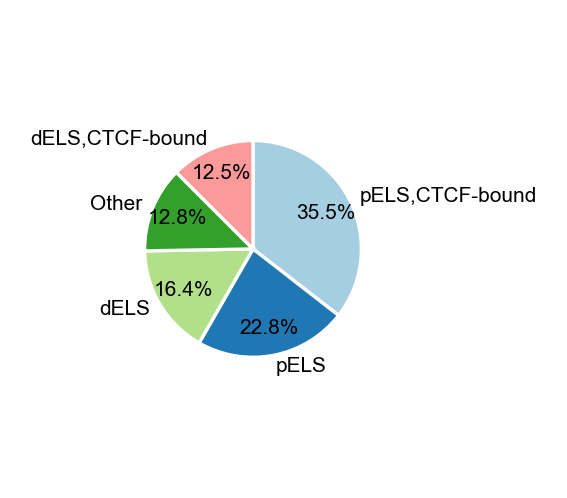

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# ATTENTION REGIONS
# =========================================================
df1 = df[df['region_type'] == 'attention'].copy()

# =========================================================
# ORIGINAL cCRE TYPE COUNTS / PROPORTIONS
# =========================================================
summary_raw = df1['cres_type'].value_counts().rename_axis('cres_type').reset_index(name='count')
summary_raw['percent'] = summary_raw['count'] / summary_raw['count'].sum()

# 与原绘图逻辑一致：
# percent > 0.1 的类型单独显示，其余合并为 Other
summary_raw['plot_cres_type'] = summary_raw.apply(lambda row: row['cres_type'] if row['percent'] > 0.1 else 'Other', axis=1)

# =========================================================
# COLLAPSED DATA USED FOR PIE CHART
# =========================================================
summary_type = summary_raw.groupby('plot_cres_type', as_index=False).agg(count=('count', 'sum'), percent=('percent', 'sum'))
summary_type = summary_type.rename(columns={'plot_cres_type': 'cres_type'})
summary_type = summary_type.sort_values('percent', ascending=False).reset_index(drop=True)

print(summary_type)

# =========================================================
# SOURCE DATA
# =========================================================
source_data = summary_type.copy()
source_data['eid'] = _eid
source_data['cell_type'] = source_data['eid'].map(EIDS_TO_CELLTYPES)
source_data['region_type'] = 'attention'
source_data['region_group'] = 'High-attention regions'

source_columns = ['eid', 'cell_type', 'region_type', 'region_group', 'cres_type', 'count', 'percent']
source_data = source_data[source_columns]

source_dir = 'scripts/figures/v8/source_data'
os.makedirs(source_dir, exist_ok=True)
source_data.to_csv(f'{source_dir}/fig4f_2.csv', index=False)

print(f'Source data saved to {source_dir}/fig4f_2.csv')
print(source_data)

# =========================================================
# PIE CHART
# =========================================================
colors = plt.cm.Paired(range(len(summary_type)))

fig, ax = plt.subplots(figsize=(4.5/2.54, 4.5/2.54))

wedges, texts, autotexts = ax.pie(summary_type['percent'], labels=summary_type['cres_type'], colors=colors, autopct=lambda p: f'{p:.1f}%' if p > 1 else '', pctdistance=0.75, textprops={'fontsize': 5, 'color': 'black'}, startangle=90, counterclock=False)

for t in autotexts:
    t.set_fontsize(5)

ax.axis('equal')

plt.tight_layout()
plt.savefig(f'extra/figures/v8/Figure4F_2_{_eid}.pdf', format='pdf', bbox_inches='tight')
plt.show()

Source data saved to scripts/figures/v8/source_data/fig4f.csv
region_group
High-attention region    18749
Low-attention region     59028
dtype: int64
U = 908592456.5
pval = 0.0000000000e+00
n_high = 18749
n_low = 59028
     region_type      mean       std  count       sem
0      attention  0.485309  0.252600  18749  0.001845
1  non_attention  0.203861  0.150443  59028  0.000619


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_66165/2855072459.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=agg_overlap, x='cres_density', y='region_type', palette=['#E64B35', '#4DBBD5'], order=order, linewidth=0.5, cut=0, scale='width')
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_66165/2855072459.py:70: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(data=agg_overlap, x='cres_density', y='region_type', palette=['#E64B35', '#4DBBD5'], order=order, linewidth=0.5, cut=0, scale='width')
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_66165/2855072459.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fix

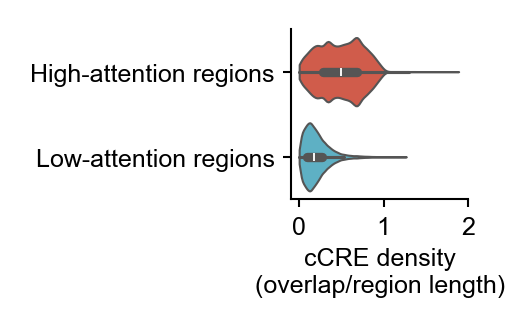

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

_eid = 'E116'

# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv(f'extra/results/attention_overlap_{_eid}.csv')

# ---- 计算每个区域的长度 ----
df['region_length'] = df['region_end'] - df['region_start']

# ---- 对每个 region 汇总 overlap 长度 ----
agg_overlap = df.groupby(['gene_id', 'region_type', 'region_start', 'region_end'], as_index=False).agg(overlap_length=('overlap_length', 'sum'), region_length=('region_end', lambda x: x.iloc[0] - df.loc[x.index[0], 'region_start']))

agg_overlap['cres_density'] = agg_overlap['overlap_length'] / agg_overlap['region_length']

# =========================================================
# SOURCE DATA
# =========================================================
source_data = agg_overlap.copy()
source_data['eid'] = _eid
source_data['cell_type'] = source_data['eid'].map(EIDS_TO_CELLTYPES)
source_data['region_group'] = source_data['region_type'].map({'attention': 'High-attention region', 'non_attention': 'Low-attention region'})

source_columns = ['eid', 'cell_type', 'gene_id', 'region_type', 'region_group', 'region_start', 'region_end', 'region_length', 'overlap_length', 'cres_density']
source_data = source_data[source_columns]

source_dir = 'scripts/figures/v8/source_data'
os.makedirs(source_dir, exist_ok=True)
source_data.to_csv(f'{source_dir}/fig4f.csv', index=False)

print(f'Source data saved to {source_dir}/fig4f.csv')
print(source_data.groupby('region_group').size())

# =========================================================
# STATISTICAL TEST
# =========================================================
att = agg_overlap.query("region_type == 'attention'")['cres_density'].dropna()
non = agg_overlap.query("region_type == 'non_attention'")['cres_density'].dropna()

stat, pval = mannwhitneyu(att, non, alternative='two-sided')

print(f'U = {stat}')
print(f'pval = {pval:.10e}')
print(f'n_high = {len(att)}')
print(f'n_low = {len(non)}')

# =========================================================
# SUMMARY
# =========================================================
summary = agg_overlap.groupby('region_type')['cres_density'].agg(['mean', 'std', 'count']).reset_index()
summary['sem'] = summary['std'] / np.sqrt(summary['count'])

print(summary)

# =========================================================
# PLOT
# =========================================================
order = ['attention', 'non_attention']

plt.figure(figsize=(4.5/2.54, 3/2.54))

ax = sns.violinplot(data=agg_overlap, x='cres_density', y='region_type', palette=['#E64B35', '#4DBBD5'], order=order, linewidth=0.5, cut=0, scale='width')

ax.set_xlabel('cCRE density\n(overlap/region length)')
ax.set_ylabel('')
ax.set_yticklabels(['High-attention regions', 'Low-attention regions'])

xticks = [0, 1, 2]
ax.set_xticks(xticks, labels=[str(tick) for tick in xticks])

plt.tight_layout()

plt.savefig(f'extra/figures/v8/Figure4F_1_{_eid}.pdf', format='pdf', bbox_inches='tight')
plt.show()


# Supplementary

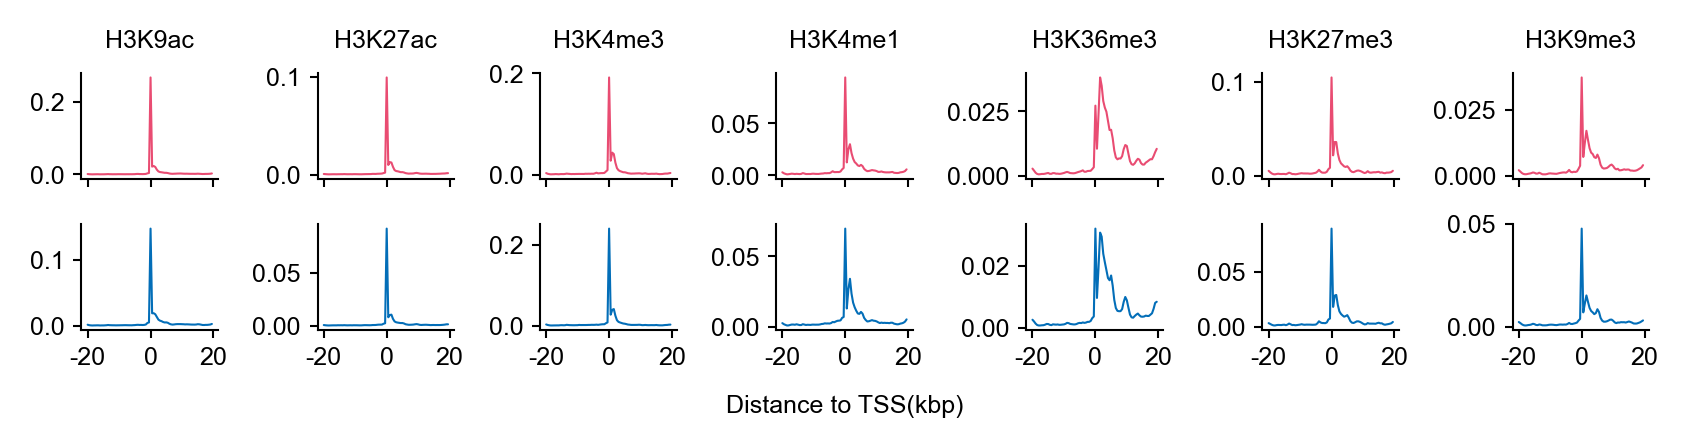

In [4]:
COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
idxes = [MARKS.index(mark) for mark in yticks]
eid = 'E003'
with open(f'extra/results/{eid}_bf_deeplift_attributions.npy','rb') as f:
   attributions1_E003 =  np.load(f)

with open(f'extra/results/{eid}_bs_deeplift_attributions.npy','rb') as f:
   attributions2_E003 =  np.load(f)


eid = 'E116'
with open(f'extra/results/{eid}_bf_deeplift_attributions.npy','rb') as f:
   attributions1_E116 =  np.load(f)

with open(f'extra/results/{eid}_bs_deeplift_attributions.npy','rb') as f:
   attributions2_E116 =  np.load(f)




eid = 'E118'
with open(f'extra/results/{eid}_bf_deeplift_attributions.npy','rb') as f:
   attributions1_E118 =  np.load(f)

with open(f'extra/results/{eid}_bs_deeplift_attributions.npy','rb') as f:
   attributions2_E118 =  np.load(f)



attributions1 = (attributions1_E003 + attributions1_E116 + attributions1_E118) / 3
attributions2 = (attributions2_E003 + attributions2_E116 + attributions2_E118) / 3
attributions1 = attributions1[idxes]
attributions2 = attributions2[idxes]

fig, ax = plt.subplots(2, 7, constrained_layout=True, figsize=(14/2.54, 3.5/2.54))
palette = ['#E94C72','#036EB8']
xticks = [i for i in range(0, 81, 10)]
for _idx, ytick in enumerate(yticks):
   sns.lineplot(attributions1[_idx],label=ytick,ax=ax[0,_idx],color = palette[0],linewidth=0.5)
   ax[0,_idx].legend().remove()
   xticklabels = [int((i - 40) / 2) for i in range(0, 41, 20)]
   ax[0,_idx].set_xticks(np.arange(0, 81,40),labels='')
   ax[0,_idx].set_xlabel(f"",ha='center')


   ax[0,_idx].set_title(ytick)


for _idx, ytick in enumerate(yticks):
   sns.lineplot(attributions2[_idx],label=ytick,ax=ax[1,_idx],color = palette[1],linewidth=0.5)
   ax[1,_idx].legend().remove()
   xticklabels = [int((i - 40) / 2) for i in range(0, 81, 40)]
   ax[1,_idx].set_xticks(np.arange(0, 81,40),labels=xticklabels)
   ax[1,_idx].set_xlabel(f"", fontsize=6,ha='center')

fig.supxlabel(f"Distance to TSS(kbp)",)
# fig.supylabel(f"", y=0.6,ha='center')

import matplotlib.lines as mlines
legend_lines = [
    mlines.Line2D([], [], color="#0071AC", linestyle="-", label='Burst frequency'),
    mlines.Line2D([], [], color="#E08800", linestyle="-", label='Burst size'),

]

# fig.legend(handles=legend_lines, title="Burst kinetics",loc="upper left", bbox_to_anchor=(0.99, 1.02), title_fontsize=6,fontsize=5, ncol=1,edgecolor='none')



plt.savefig(f'extra/figures/v7/Supplementary_Figure7A.eps', format='eps', bbox_inches='tight')

plt.show()

# Supplementary Figure7B

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_83298/3546377854.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['BF-', 'BF+'], fontsize=6)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_83298/3546377854.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['BS-', 'BS+'],fontsize=6)


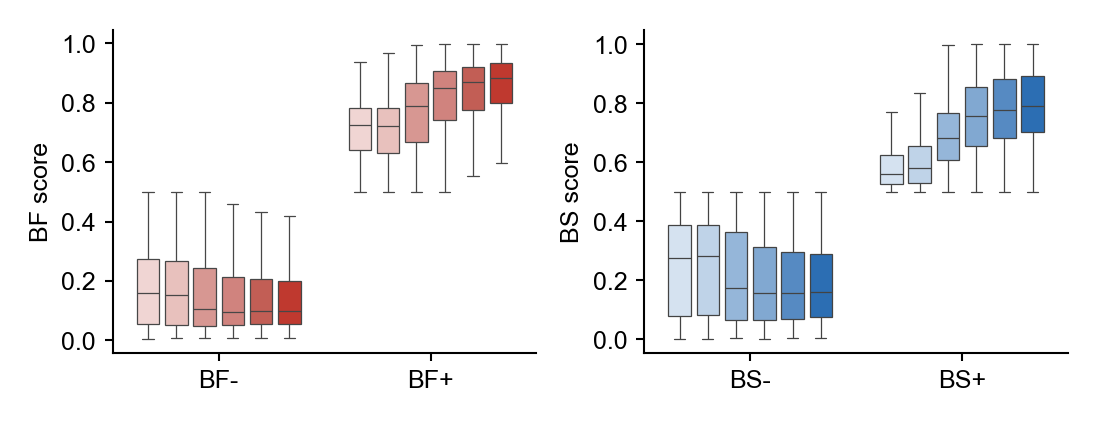

In [18]:
fig, ax = plt.subplots(1,2,constrained_layout=True,figsize=(9/2.54, 3.5/2.54))

data = pd.read_csv('extra/results/distance_region_predictions_bs_bf.csv')

palette = {
    1000: '#F0D5D3',
    2000: '#E8C1BD',
    5000: '#D79792',
    10000: '#D0837E',
    20000: '#C25E55',
    40000: '#BF392F'
}

sns.boxplot(data=data,
            x='bf_label_pred',
            y='bf_label_score',
            hue='window_size',
            palette=palette,
            fliersize=0,
            linewidth=0.3,
            width=0.8,
            gap=0.2,
            ax=ax[0],
            saturation=1,
            )


palette = {
    1000: '#D5E2F0',
    2000: '#BFD3E8',
    5000: '#95B6D9',
    10000: '#81A8D1',
    20000: '#568AC2',
    40000: '#2C6EB3'
}

sns.boxplot(data=data,
            x='bs_label_pred',
            y='bs_label_score',
            hue='window_size',
            palette=palette,
            fliersize=0,
            linewidth=0.3,   
            width=0.8, 
            gap=0.2,        
            ax=ax[1],
            saturation=1,
            )

handles, labels = ax[0].get_legend_handles_labels()
labels = ["1","2","5","10","20","40"]
ax[0].legend().remove()
ax[0].set_ylabel('BF score')
ax[0].set_xlabel('')
ax[0].set_xticklabels(['BF-', 'BF+'], fontsize=6)
# ax[0].set_title('')


ax[1].legend().remove()
ax[1].set_ylabel('BS score')
ax[1].set_xlabel('')
ax[1].set_xticklabels(['BS-', 'BS+'],fontsize=6)
fig.supxlabel('')
# fig.supxlabel('Label',x=0.55,y=-0.05)
# legend = fig.legend(handles, labels, title= 'Region Surrounding\nTSS (kbp)', loc='upper left', bbox_to_anchor=(0.98, 1.02), title_fontsize=6,fontsize=5,ncol=1,edgecolor='none',handlelength=1.3 ,columnspacing=1.5)
# plt.setp(legend.get_title(), horizontalalignment='center')
plt.savefig('extra/figures/v7/Supplementary_Figure7B.eps', format='eps', bbox_inches='tight')
plt.show()

In [28]:
data[data['window_size']==1000]

,gene_id,bs_label_label,bs_label_score,bs_label_pred,bf_label_label,bf_label_score,bf_label_pred,eid,fold,window_size
0,ENSG00000136098,0,0.403596,0,0,0.418431,0,E116,0,1000
1,ENSG00000185813,1,0.799804,1,1,0.840753,1,E116,0,1000
2,ENSG00000176774,0,0.069217,0,0,0.056843,0,E116,0,1000
3,ENSG00000105696,0,0.135971,0,0,0.156057,0,E116,0,1000
4,ENSG00000161082,0,0.129061,0,0,0.184513,0,E116,0,1000
...,...,...,...,...,...,...,...,...,...,...
195292,ENSG00000077380,0,0.866795,1,1,0.966957,1,E003,3,1000
195293,ENSG00000101654,1,0.863340,1,1,0.948218,1,E003,3,1000
195294,ENSG00000071282,1,0.563573,1,0,0.382164,0,E003,3,1000
195295,ENSG00000163295,0,0.067893,0,0,0.040738,0,E003,3,1000


# motif analysis

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_49669/3471903309.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['TATA','Inr','CCAAT','GCbox'],ha='center',fontsize=5)


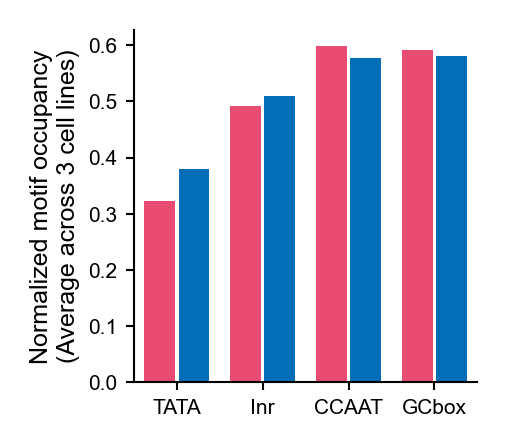

In [ ]:
motif_indicatores = pd.read_csv('extra/results/bs_bf_motif_indicators_pred.csv')
motif_indicatores
palette = ['#E94C72','#036EB8']
fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(4/2.54, 3.5/2.54))
hue_order = ['bf_label_pred','bs_label_pred']
sns.barplot(data=motif_indicatores,x='motif',y='ratio',hue='target',palette=palette,
            linewidth=0.0,            
            ax=ax,
            saturation=1,
            width=0.8,
            gap=0.1,
            hue_order=hue_order,
        )


ax.set_xticklabels(['TATA','Inr','CCAAT','GCbox'],ha='center',fontsize=5)
ax.legend().remove()
ax.set_xlabel('', fontsize=6,fontweight='regular')
ax.set_ylabel('Normalized motif occupancy\n(Average across 3 cell lines)', fontsize=6,fontweight='regular')
legend_patches = [
    mpatches.Patch(color=palette[0], label='BF+'),
    mpatches.Patch(color=palette[1], label='BS+'),
]
# fig.legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(0.95, 1.05) , title_fontsize=6,fontsize=5,ncol=1,edgecolor='none')

plt.savefig(f'extra/figures/v6/Figure4F.eps', format='eps', bbox_inches='tight')
plt.show()